# MOMARL Results Visualization

Visualize Multi-Objective Multi-Agent RL training results from WandB logs.

**Features:** Pareto front, hypervolume comparison, hypervolume learning curve

## 1. Configuration

In [ ]:
from pathlib import Path

# Paths
RESULTS_DIR = Path("../../momarl_results/momarl_12_agents_comparison")
OUTPUT_DIR = Path("./figures")

# Hypervolume reference point (origin for maximization)
HYPERVOLUME_REF_POINT = [0.0, 0.0]

# Objective names for axis labels
# objectives are: "global_economic_output", "welfare", "temperature_threshold", "inverse_global_temperature"
OBJECTIVE_NAMES = ["inverse_global_temperature", "global_economic_output"]

# Plot settings
ALGORITHM_COMPARISON = True  # Set to False to plot only one algorithm
COLORS = {"HAPPO": "#133eb6", "MAPPO": "#ff0e76", "UNKNOWN": "#ffb6c1"}
FIGURE_DPI = 150
SAVE_FIGURES = True

# Filter runs with returns below these thresholds (set to None to disable)
MIN_RETURN_OBJ_0 = 0.0
MIN_RETURN_OBJ_1 = 0.0

# WandB settings
USE_WANDB_API = True
WANDB_PROJECT = "momarl_happo_mappo"
WANDB_ENTITY = "olaandrasz-tu-delft"

## 2. Imports

In [118]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass
import warnings

# Hypervolume (DEAP)
try:
    from deap.tools._hypervolume import hv
    HV_AVAILABLE = True
except ImportError:
    HV_AVAILABLE = False
    warnings.warn("DEAP not installed - hypervolume unavailable")

# WandB
try:
    import wandb
    WANDB_AVAILABLE = True
except ImportError:
    WANDB_AVAILABLE = False
    warnings.warn("wandb not installed")

if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"HV: {HV_AVAILABLE}, WandB: {WANDB_AVAILABLE}")

if WANDB_AVAILABLE and USE_WANDB_API:
    try:
        wandb.login()
        print("WandB login successful")
    except Exception as e:
        print(f"WandB login failed: {e}")

HV: True, WandB: True
WandB login successful


## 3. Data Loading

In [119]:
def load_json(path: Path) -> Optional[Dict]:
    if not path.exists():
        return None
    with open(path, 'r') as f:
        return json.load(f)

def load_yaml(path: Path) -> Optional[Dict]:
    if not path.exists():
        return None
    import yaml
    with open(path, 'r') as f:
        return yaml.safe_load(f)


def parse_run(run_dir: Path) -> Optional[Dict]:
    """Parse a single WandB run directory into a dict."""
    metadata = load_json(run_dir / "files" / "wandb-metadata.json")
    summary = load_json(run_dir / "files" / "wandb-summary.json")
    config = load_yaml(run_dir / "files" / "config.yaml")
    
    if metadata is None or summary is None:
        return None
    
    run_name = run_dir.name
    weights = summary.get("weights", [0.5, 0.5])
    rewards = config.get("rewards", {}).get("value", []) if config else []
    
    return {
        "run_id": run_name,
        "algorithm": config.get("algorithm", {}).get("value", "UNKNOWN").upper() if config else "UNKNOWN",
        "weight_0": weights[0] if weights else 0.0,
        "weight_1": weights[1] if len(weights) > 1 else 0.0,
        "weight_idx": summary.get("weight_idx", -1),
        "reward_0": rewards[0] if len(rewards) > 0 else "",
        "reward_1": rewards[1] if len(rewards) > 1 else "",
        "return_obj_0": summary.get("return_obj_0") or summary.get("final/return_obj_0") or 0.0,
        "return_obj_1": summary.get("return_obj_1") or summary.get("final/return_obj_1") or 0.0,
        "total_steps": summary.get("total_num_steps", 0),
    }


def load_all_runs(results_dir: Path) -> pd.DataFrame:
    """Load all WandB runs from a directory into a DataFrame."""
    run_dirs = sorted([d for d in results_dir.iterdir() if d.is_dir() and d.name.startswith("run-")])
    rows = [parse_run(d) for d in run_dirs]
    rows = [r for r in rows if r is not None]
    return pd.DataFrame(rows) if rows else pd.DataFrame()

## 4. Load Runs

In [120]:
df = load_all_runs(RESULTS_DIR)

print(f"Loaded {len(df)} runs from {RESULTS_DIR}")
print(df["algorithm"].value_counts())
print(df["reward_0"].value_counts())
print(df["reward_1"].value_counts())

# Filter based on OBJECTIVE_0 and OBJECTIVE_1 names
if OBJECTIVE_NAMES[0] and OBJECTIVE_NAMES[1]:
    df = df[
        (df["reward_0"] == OBJECTIVE_NAMES[0]) &
        (df["reward_1"] == OBJECTIVE_NAMES[1])
    ]
    
print(f"\nAfter filtering by reward names: {len(df)} runs")
print(df["reward_0"].value_counts())
print(df["reward_1"].value_counts())
df.head(10)

Loaded 240 runs from ../../momarl_results/momarl_12_agents_comparison
algorithm
HAPPO      100
MAPPO      100
UNKNOWN     40
Name: count, dtype: int64
reward_0
inverse_global_temperature    200
                               40
Name: count, dtype: int64
reward_1
global_economic_output    200
                           40
Name: count, dtype: int64

After filtering by reward names: 200 runs
reward_0
inverse_global_temperature    200
Name: count, dtype: int64
reward_1
global_economic_output    200
Name: count, dtype: int64


,run_id,algorithm,weight_0,weight_1,weight_idx,reward_0,reward_1,return_obj_0,return_obj_1,total_steps
0,run-20260327_182112-xtzjkh0p,HAPPO,0.000000,1.000000,0,inverse_global_temperature,global_economic_output,86.633897,344.309252,2479500
1,run-20260327_183039-rxzc9e0k,HAPPO,0.050067,0.949933,0,inverse_global_temperature,global_economic_output,93.590734,341.651824,2479500
2,run-20260327_183538-fyv0knzt,HAPPO,0.100278,0.899722,0,inverse_global_temperature,global_economic_output,95.423687,346.618703,2479500
3,run-20260327_183538-kn5reoz9,HAPPO,0.150527,0.849473,0,inverse_global_temperature,global_economic_output,101.281402,346.128959,2479500
4,run-20260327_192800-tul833by,HAPPO,0.200736,0.799264,0,inverse_global_temperature,global_economic_output,110.485277,349.144202,2479500
5,run-20260327_193923-bg15og7c,HAPPO,0.251196,0.748804,0,inverse_global_temperature,global_economic_output,114.318089,349.611936,2479500
6,run-20260327_193923-ckaud1sk,HAPPO,0.301663,0.698337,0,inverse_global_temperature,global_economic_output,116.679538,340.301032,2479500
7,run-20260327_194854-msoosz4g,HAPPO,0.352273,0.647727,0,inverse_global_temperature,global_economic_output,121.436624,347.232534,2479500
8,run-20260327_195633-yom93zev,HAPPO,0.402745,0.597255,0,inverse_global_temperature,global_economic_output,122.349244,347.153334,2479500
9,run-20260327_195633-ytp5eu4x,HAPPO,0.453308,0.546692,0,inverse_global_temperature,global_economic_output,121.559361,343.015129,2479500


## 5. Pareto Front

In [121]:
MARKERS = {"HAPPO": "o", "MAPPO": "s", "UNKNOWN": "o"}

# Plotly markers (different naming)
PLOTLY_MARKERS = {"HAPPO": "circle", "MAPPO": "square", "UNKNOWN": "circle"}

try:
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print("Plotly not installed - interactive plots unavailable")


def is_pareto_efficient(points: np.ndarray) -> np.ndarray:
    """Return boolean mask of Pareto-efficient points (maximization)."""
    n = len(points)
    is_efficient = np.ones(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i != j and np.all(points[j] >= points[i]) and np.any(points[j] > points[i]):
                is_efficient[i] = False
                break
    return is_efficient


def plot_pareto_front_interactive(df: pd.DataFrame) -> go.Figure:
    """Plot interactive Pareto front with hover info (weight, run_id).
    Includes checkbox to show/hide dominated (non-Pareto) points."""
    fig = go.Figure()
    
    algos = list(df["algorithm"].unique())
    if not ALGORITHM_COMPARISON and len(algos) > 1:
        # When only a single algorithm should be shown, select the most frequent one
        algos = [df["algorithm"].value_counts().idxmax()]
    
    dominated_trace_indices = []  # Track indices of dominated point traces
    trace_idx = 0
    
    for algo in algos:
        algo_df = df[df["algorithm"] == algo].reset_index(drop=True)
        points = algo_df[["return_obj_0", "return_obj_1"]].values
        color = COLORS.get(algo, "#333")
        marker = PLOTLY_MARKERS.get(algo, "circle")
        
        pareto_mask = is_pareto_efficient(points) if len(points) > 0 else np.zeros(len(points), dtype=bool)
        non_pareto_mask = ~pareto_mask
        
        # Create hover text with weight and run_id
        hover_text = [
            f"Run: {row['run_id']}<br>Weight: ({row['weight_0']:.2f}, {row['weight_1']:.2f})<br>"
            f"{OBJECTIVE_NAMES[0]}: {row['return_obj_0']:.2f}<br>{OBJECTIVE_NAMES[1]}: {row['return_obj_1']:.2f}"
            for _, row in algo_df.iterrows()
        ]
        
        # Add dominated (non-Pareto) points first (faded, hidden by default)
        if non_pareto_mask.any():
            non_pareto_df = algo_df[non_pareto_mask]
            non_pareto_hover = [hover_text[i] for i in range(len(algo_df)) if non_pareto_mask[i]]
            fig.add_trace(go.Scatter(
                x=non_pareto_df["return_obj_0"],
                y=non_pareto_df["return_obj_1"],
                mode="markers",
                marker=dict(size=10, color=color, symbol=marker, opacity=0.4,
                           line=dict(width=1, color="gray")),
                name=f"{algo} (dominated)",
                hovertemplate="%{customdata}<extra></extra>",
                customdata=non_pareto_hover,
                visible=False  # Hidden by default
            ))
            dominated_trace_indices.append(trace_idx)
            trace_idx += 1
        
        # Add Pareto points (highlighted)
        if pareto_mask.any():
            pareto_df = algo_df[pareto_mask]
            pareto_hover = [hover_text[i] for i in range(len(algo_df)) if pareto_mask[i]]
            fig.add_trace(go.Scatter(
                x=pareto_df["return_obj_0"],
                y=pareto_df["return_obj_1"],
                mode="markers",
                marker=dict(size=14, color=color, symbol=marker, 
                           line=dict(width=2, color="gray")),
                name=f"{algo} (Pareto)",
                hovertemplate="%{customdata}<extra></extra>",
                customdata=pareto_hover
            ))
            trace_idx += 1
    
    # Create visibility arrays for toggle buttons
    n_traces = len(fig.data)
    # Pareto only: dominated traces hidden
    pareto_only_visible = [True] * n_traces
    for i in dominated_trace_indices:
        pareto_only_visible[i] = False
    
    # All points: everything visible
    all_visible = [True] * n_traces
    
    title_text = "Pareto Front"
    if ALGORITHM_COMPARISON:
        title_text += ": HAPPO vs MAPPO"
    
    fig.update_layout(
        title=dict(text=title_text, font=dict(size=16, weight="bold")),
        xaxis_title=OBJECTIVE_NAMES[0].replace('_', ' ').title(),
        yaxis_title=OBJECTIVE_NAMES[1].replace('_', ' ').title(),
        legend=dict(x=0.98, y=0.98, xanchor="right", yanchor="bottom"),
        hovermode="closest",
        width=900,
        height=650,
        # Add toggle buttons
        updatemenus=[
            dict(
                type="buttons",
                direction="left",
                buttons=[
                    dict(
                        args=[{"visible": pareto_only_visible}],
                        label="Pareto Only",
                        method="update"
                    ),
                    dict(
                        args=[{"visible": all_visible}],
                        label="Show All Points",
                        method="update"
                    ),
                ],
                pad={"r": 10, "t": 10},
                showactive=True,
                x=0.0,
                xanchor="left",
                y=1.12,
                yanchor="top"
            ),
        ],
    )
    
    return fig


def plot_pareto_front(df: pd.DataFrame, show_weights: bool = True) -> plt.Figure:
    """Plot Pareto front comparison between algorithms (static matplotlib)."""
    fig, ax = plt.subplots(figsize=(12, 8))
    
    algos = list(df["algorithm"].unique())
    if not ALGORITHM_COMPARISON and len(algos) > 1:
        # When only a single algorithm should be shown, select the most frequent one
        algos = [df["algorithm"].value_counts().idxmax()]
    
    for algo in algos:
        algo_df = df[df["algorithm"] == algo]
        points = algo_df[["return_obj_0", "return_obj_1"]].values
        color, marker = COLORS.get(algo, "#333"), MARKERS.get(algo, "x")
        
        pareto_mask = is_pareto_efficient(points) if len(points) > 0 else np.zeros(len(points), dtype=bool)
        
        # Pareto (highlighted)
        if pareto_mask.any():
            if ALGORITHM_COMPARISON:
                ax.scatter(points[pareto_mask, 0], points[pareto_mask, 1],
                      c=color, s=150, marker=marker, alpha=0.9,
                      edgecolors='black', linewidths=1.5, label=f"{algo}")
            else:
                ax.scatter(points[pareto_mask, 0], points[pareto_mask, 1],
                      c=color, s=150, marker=marker, alpha=0.9,
                      edgecolors='gray', linewidths=1.5, label=f"{OBJECTIVE_NAMES}")
        
        # Weight annotations
        if show_weights:
            for _, row in algo_df.iterrows():
                ax.annotate(f"({row['weight_0']:.2f}, {row['weight_1']:.2f})",
                           (row["return_obj_0"], row["return_obj_1"]),
                           textcoords="offset points", xytext=(5, 5 if algo == "HAPPO" else -12),
                           fontsize=7, color=color, alpha=0.8)
    
    ax.set_xlabel(OBJECTIVE_NAMES[0].replace('_', ' ').title(), fontsize=12)
    ax.set_ylabel(OBJECTIVE_NAMES[1].replace('_', ' ').title(), fontsize=12)
    title = "Pareto Front"
    if ALGORITHM_COMPARISON:
        title += ": HAPPO vs MAPPO"
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

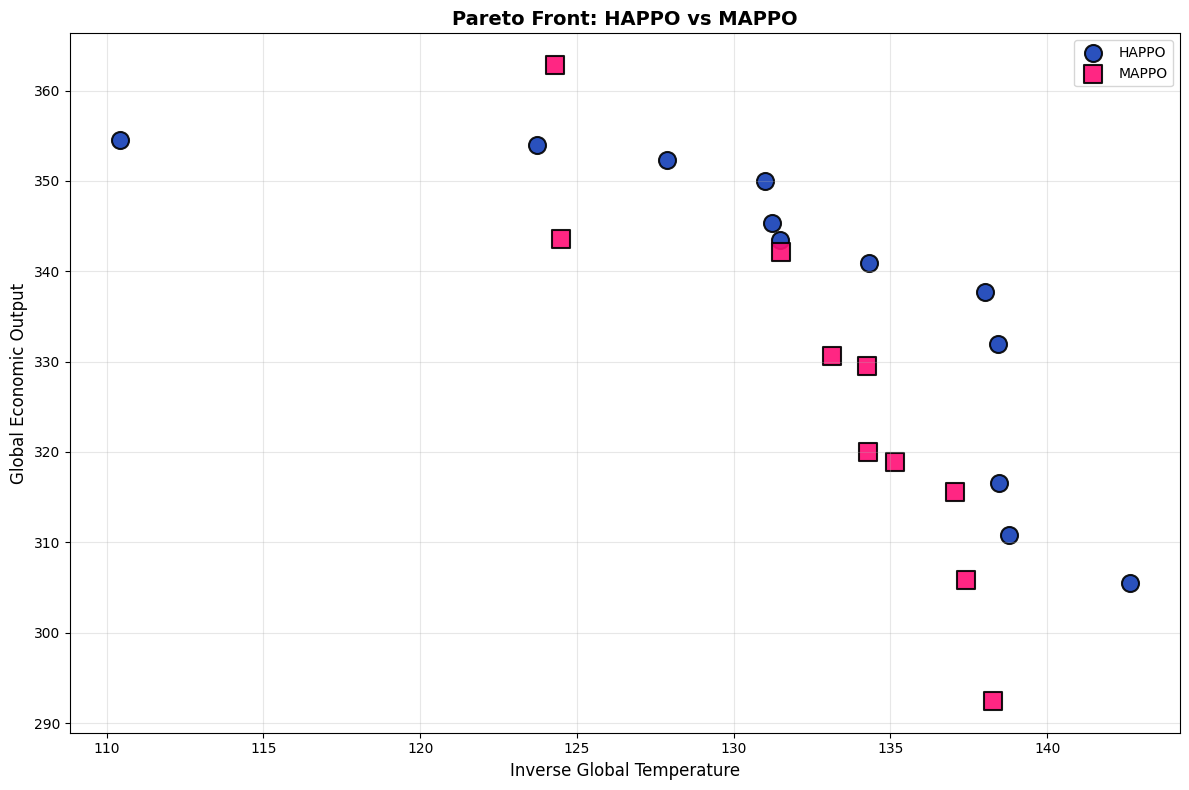

In [122]:
# Interactive plot with hover (Plotly)
if PLOTLY_AVAILABLE:
    fig_pareto_interactive = plot_pareto_front_interactive(df)
    fig_pareto_interactive.show()
else:
    print("Plotly not available, showing static plot")

# Static plot (matplotlib) - for saving
fig_pareto = plot_pareto_front(df, show_weights=False)
if SAVE_FIGURES:
    fig_pareto.savefig(OUTPUT_DIR / "pareto_front.png", dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()

## 6. Hypervolume Over Time

In [123]:
def fetch_training_history_from_wandb(runs_df, entity: str, project: str) -> Dict[str, pd.DataFrame]:
    """Fetch eval history for all runs from WandB API.
    Returns histories dict with algorithm info embedded in each DataFrame.
    Columns: run_id, algorithm, total_num_steps, 0, 1, objective_vectors (list of arrays)."""
    api = wandb.Api()
    
    histories = {}
    i = 0 
    for run_id, algorithm in zip(runs_df["run_id"], runs_df["algorithm"]):
        
        run_new_id = run_id.split("-")[-1] if "-" in run_id else run_id
        if i % 50 == 0:
            print(f"Fetching history for run {i}/{len(runs_df)}")
        i += 1
        try:
            online_data = api.run(f"{entity}/{project}/{run_new_id}")
        except Exception as e:
            print(f"Failed to fetch run with path {entity}/{project}/{run_new_id}: \n{e}")
            continue
    
        # Fetch each key separately to avoid wandb dropping rows where not all keys are present
        hist_0_means = online_data.history(keys=["eval/0_mean"], pandas=True)
        hist_1_means = online_data.history(keys=["eval/1_mean"], pandas=True)
        hist_total_steps = online_data.history(keys=["total_num_steps"], pandas=True)
        hist_objective_vector = online_data.history(keys=["eval/objective_vector"], pandas=True)
        
        if hist_0_means.empty and hist_1_means.empty:
            print(f"No eval data for {run_new_id}, skipping")
            continue
        
        # Merge on _step index (wandb adds _step column to each history call)
        history_df = pd.DataFrame({"_step": hist_0_means.get("_step", pd.Series(dtype=int))})
        history_df["0"] = hist_0_means.get("eval/0_mean", pd.Series(dtype=float)).values
        
        if not hist_1_means.empty and "_step" in hist_1_means.columns:
            h1 = hist_1_means[["_step", "eval/1_mean"]].rename(columns={"eval/1_mean": "1"})
            history_df = history_df.merge(h1, on="_step", how="outer")
        else:
            history_df["1"] = np.nan
        
        if not hist_total_steps.empty and "_step" in hist_total_steps.columns:
            ht = hist_total_steps[["_step", "total_num_steps"]]
            history_df = history_df.merge(ht, on="_step", how="outer")
        else:
            history_df["total_num_steps"] = np.nan
        
        history_df = history_df.sort_values("_step").reset_index(drop=True)
        history_df["total_num_steps"] = history_df["total_num_steps"].ffill().bfill()
        history_df["run_id"] = run_id
        history_df["algorithm"] = algorithm
        
        # Parse objective_vector column: wandb Tables come back as dicts or strings
        obj_vectors = []
        vec_col = hist_objective_vector.get("eval/objective_vector")
        vec_steps = hist_objective_vector.get("_step")
        
        # Build a step -> vector mapping
        vec_by_step = {}
        if vec_col is not None and vec_steps is not None:
            for step_val, val in zip(vec_steps, vec_col):
                if val is None or (isinstance(val, float) and np.isnan(val)):
                    vec_by_step[step_val] = None
                elif isinstance(val, dict) and "data" in val:
                    vec_by_step[step_val] = np.array(val["data"])
                elif isinstance(val, list):
                    vec_by_step[step_val] = np.array(val)
                elif isinstance(val, str):
                    import json as _json
                    try:
                        parsed = _json.loads(val)
                        if isinstance(parsed, dict) and "data" in parsed:
                            vec_by_step[step_val] = np.array(parsed["data"])
                        else:
                            vec_by_step[step_val] = np.array(parsed)
                    except Exception:
                        vec_by_step[step_val] = None
                else:
                    vec_by_step[step_val] = None
        
        # Align vectors with history_df rows by _step
        history_df["objective_vectors"] = [vec_by_step.get(s) for s in history_df["_step"]]
        history_df = history_df.drop(columns=["_step"])
        
        histories[run_id] = history_df
    return histories

In [124]:
# print("Fetching from WandB API...")
# api = wandb.Api()
# print(api.runs(f"{WANDB_ENTITY}/{WANDB_PROJECT}"))
# for run in api.runs(f"{WANDB_ENTITY}/{WANDB_PROJECT}"):
#     print(run.path)
# print(WANDB_ENTITY, WANDB_PROJECT)

In [ ]:
if WANDB_AVAILABLE and USE_WANDB_API and HV_AVAILABLE:
    print("Fetching from WandB API...")
    api = wandb.Api()
    # print(api.runs(f"{WANDB_ENTITY}/{WANDB_PROJECT}"))
    # for run in api.runs(f"{WANDB_ENTITY}/{WANDB_PROJECT}"):
    #     print(run.path)
    print(WANDB_ENTITY, WANDB_PROJECT)
    histories = fetch_training_history_from_wandb(df, WANDB_ENTITY, WANDB_PROJECT)
    
    # Extract algorithms from histories
    algos_found = {hist["algorithm"].iloc[0] for hist in histories.values() if len(hist) > 0}
    print(f"\nLoaded {len(histories)} runs, algorithms: {algos_found}")

Fetching from WandB API...
olaandrasz-tu-delft momarl_debug
Fetching history for run 0/200
Failed to fetch run with path olaandrasz-tu-delft/momarl_debug/xtzjkh0p: 
Could not find run <Run olaandrasz-tu-delft/momarl_debug/xtzjkh0p (not found)>
Failed to fetch run with path olaandrasz-tu-delft/momarl_debug/rxzc9e0k: 
Could not find run <Run olaandrasz-tu-delft/momarl_debug/rxzc9e0k (not found)>
Failed to fetch run with path olaandrasz-tu-delft/momarl_debug/fyv0knzt: 
Could not find run <Run olaandrasz-tu-delft/momarl_debug/fyv0knzt (not found)>
Failed to fetch run with path olaandrasz-tu-delft/momarl_debug/kn5reoz9: 
Could not find run <Run olaandrasz-tu-delft/momarl_debug/kn5reoz9 (not found)>
Failed to fetch run with path olaandrasz-tu-delft/momarl_debug/tul833by: 
Could not find run <Run olaandrasz-tu-delft/momarl_debug/tul833by (not found)>
Failed to fetch run with path olaandrasz-tu-delft/momarl_debug/bg15og7c: 
Could not find run <Run olaandrasz-tu-delft/momarl_debug/bg15og7c (not

In [ ]:
def compute_hypervolume(points: np.ndarray, ref_point: List[float]) -> float:
    """Compute hypervolume for points (maximization). DEAP assumes minimization, so we negate.

    Assumes points are already normalized or scaled as desired.
    """
    if not HV_AVAILABLE or len(points) == 0:
        return 0.0
    
    ref = np.array(ref_point)
    valid_mask = np.all(points > ref, axis=1)
    if not valid_mask.any():
        return 0.0
    
    # Negate for DEAP (minimization)
    return hv.hypervolume((-points[valid_mask]).tolist(), (-ref).tolist())


def compute_hypervolume_over_time(histories: Dict[str, pd.DataFrame],
                                   ref_point: List[float], num_bins: int = 100) -> Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray]]:
    """Compute hypervolume at each time bin for each algorithm (normalized per objective).
    
    Computes per-run HV at each bin, then returns mean ± std across runs.
    
    Returns dict: algo -> (steps, hv_mean, hv_std)
    """
    if not HV_AVAILABLE:
        return {}
    
    # Group histories by algorithm (extracted from DataFrame)
    algo_histories: Dict[str, List[pd.DataFrame]] = {}
    for run_id, hist in histories.items():
        algo = hist["algorithm"].iloc[0] if len(hist) > 0 else "UNKNOWN"
        algo_histories.setdefault(algo, []).append(hist)
    
    results = {}
    for algo, hist_list in algo_histories.items():
        # Collect ALL data points per run: run_idx -> [(steps, obj_0, obj_1), ...]
        run_data = []
        all_points_flat = []
        for hist in hist_list:
            valid_rows = hist.dropna(subset=["total_num_steps", "0", "1"])
            pts = [(row["total_num_steps"], row["0"], row["1"]) for _, row in valid_rows.iterrows()]
            run_data.append(pts)
            all_points_flat.extend(pts)
        
        if not all_points_flat:
            continue
        
        # Global normalization across all runs
        all_array = np.array([[d[1], d[2]] for d in all_points_flat])
        obj_mins = all_array.min(axis=0)
        obj_maxs = all_array.max(axis=0)
        obj_ranges = obj_maxs - obj_mins
        obj_ranges = np.where(obj_ranges == 0.0, 1.0, obj_ranges)
        
        max_steps = int(max(d[0] for d in all_points_flat))
        
        step_centers, hv_means, hv_stds = [], [], []
        
        for i in range(num_bins):
            threshold = int(max_steps * (i + 1) / num_bins)
            
            # Compute HV per run up to this threshold
            run_hvs = []
            for pts in run_data:
                run_pts = np.array([[d[1], d[2]] for d in pts if d[0] <= threshold])
                if len(run_pts) > 0:
                    run_pts_norm = (run_pts - obj_mins) / obj_ranges
                    try:
                        run_hvs.append(compute_hypervolume(run_pts_norm, ref_point))
                    except Exception:
                        pass
            
            if run_hvs:
                step_centers.append(threshold)
                hv_means.append(np.mean(run_hvs))
                hv_stds.append(np.std(run_hvs))
        
        if hv_means:
            results[algo] = (np.array(step_centers), np.array(hv_means), np.array(hv_stds))
    
    return results


def plot_hypervolume_over_time(hv_over_time: Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray]]) -> plt.Figure:
    """Plot hypervolume learning curves with std shading."""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for algo, data in hv_over_time.items():
        steps, hv_mean, hv_std = data
        color = COLORS.get(algo, "#333")
        label = algo if ALGORITHM_COMPARISON else f"{OBJECTIVE_NAMES}"
        
        ax.plot(steps, hv_mean, color=color, linewidth=2, label=label)
        ax.fill_between(steps, hv_mean - hv_std, hv_mean + hv_std,
                        color=color, alpha=0.15)
    
    ax.set_xlabel("Total Steps")
    ax.set_ylabel("Hypervolume (normalized objectives)")
    ax.set_title(f"Hypervolume Over Training (ref={HYPERVOLUME_REF_POINT})", fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

Run run-20260408_122156-4cv0c0t1 - Algorithm: HAPPO, Steps: 30, Final 0: 79.58, Final 1: 347.75
Run run-20260408_123643-a5odfgzl - Algorithm: HAPPO, Steps: 30, Final 0: 127.94, Final 1: 364.92
Run run-20260408_125103-bo3t43dn - Algorithm: HAPPO, Steps: 30, Final 0: 126.15, Final 1: 368.50
Run run-20260408_130539-lec3n3tc - Algorithm: HAPPO, Steps: 30, Final 0: 156.31, Final 1: 273.91


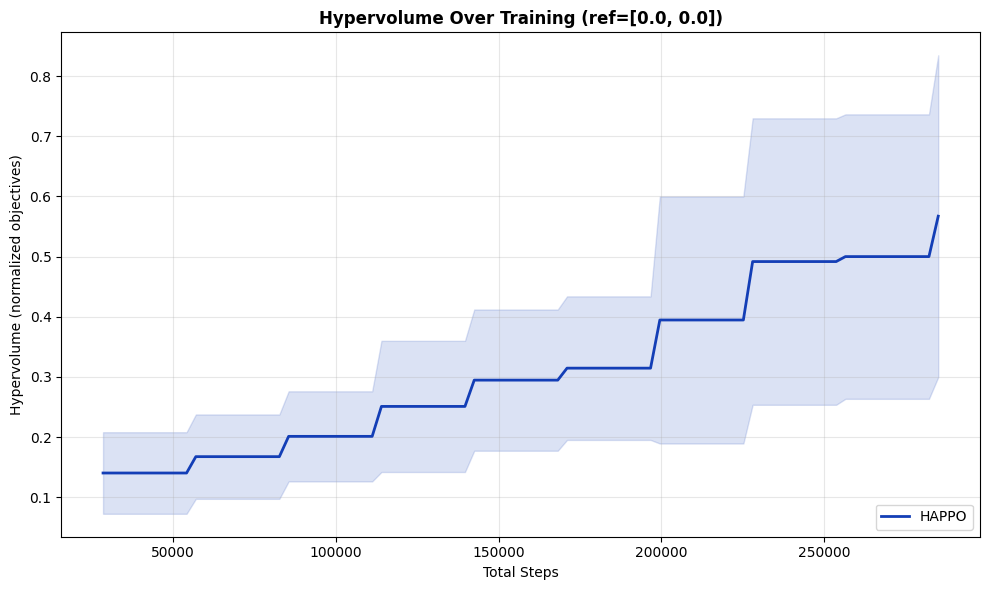

In [ ]:
for run_id in histories:
    print(f"Run {run_id} - Algorithm: {histories[run_id]['algorithm'].iloc[0]}, "
          f"Steps: {len(histories[run_id])}, "
          f"Final 0: {histories[run_id]['0'].iloc[-1]:.2f}, "
          f"Final 1: {histories[run_id]['1'].iloc[-1]:.2f}")
hv_over_time = compute_hypervolume_over_time(histories, HYPERVOLUME_REF_POINT)

if hv_over_time:
    fig_hv_time = plot_hypervolume_over_time(hv_over_time)
    if SAVE_FIGURES:
        fig_hv_time.savefig(OUTPUT_DIR / "hypervolume_over_time.png", dpi=FIGURE_DPI, bbox_inches='tight')
    plt.show()
else:
    print("No data for HV over time")


## 7. Expected Utility Over Time

In [ ]:
def compute_expected_utility_over_time(histories: Dict[str, pd.DataFrame],
                                       runs_df: pd.DataFrame,
                                       num_bins: int = 100) -> Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray]]:
    """Compute expected utility over time for each algorithm using MAX utility.

    For each eval step, the objective_vectors column contains per-episode
    returns of shape (num_episodes, num_objectives). We compute:
        EU_episode = weight_0 * norm(obj_0) + weight_1 * norm(obj_1)
    for each episode, then take the MAX across episodes at that eval step.

    Returns: algo -> (steps, eu_mean, eu_std).
    """
    results: Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray]] = {}
    
    # Group histories by algorithm
    algo_histories: Dict[str, List[pd.DataFrame]] = {}
    for run_id, hist in histories.items():
        if len(hist) == 0:
            continue
        algo = hist["algorithm"].iloc[0] if "algorithm" in hist.columns else "UNKNOWN"
        algo_histories.setdefault(algo, []).append(hist)
    
    for algo, hist_list in algo_histories.items():
        # First pass: collect all objective vectors to compute global normalization
        all_obj_points = []
        for hist in hist_list:
            for vec_arr in hist["objective_vectors"]:
                if vec_arr is not None and len(vec_arr) > 0:
                    all_obj_points.append(vec_arr)
        
        if not all_obj_points:
            # Fallback to mean columns if no objective_vectors available
            all_points = []
            for hist in hist_list:
                valid = hist.dropna(subset=["total_num_steps", "0", "1"])
                for _, row in valid.iterrows():
                    all_points.append((row["0"], row["1"]))
            if not all_points:
                continue
            all_array = np.array(all_points)
        else:
            all_array = np.vstack(all_obj_points)
        
        obj_mins = all_array.min(axis=0)
        obj_maxs = all_array.max(axis=0)
        obj_ranges = obj_maxs - obj_mins
        obj_ranges = np.where(obj_ranges == 0.0, 1.0, obj_ranges)
        
        # Second pass: compute max EU per eval step, grouped by run
        # run_data[i] = [(step, max_eu), ...]
        run_data: List[List[Tuple[float, float]]] = []
        
        for hist in hist_list:
            if len(hist) == 0:
                continue
            run_id = hist["run_id"].iloc[0] if "run_id" in hist.columns else None
            if run_id is None:
                continue
            match = runs_df[runs_df["run_id"] == run_id]
            if match.empty:
                continue
            w0 = float(match["weight_0"].iloc[0])
            w1 = float(match["weight_1"].iloc[0])

            run_pts = []
            for _, row in hist.iterrows():
                step = row.get("total_num_steps")
                if step is None or (isinstance(step, float) and np.isnan(step)):
                    continue
                
                vec_arr = row.get("objective_vectors")
                if vec_arr is not None and len(vec_arr) > 0:
                    normed = (np.array(vec_arr) - obj_mins) / obj_ranges
                    eu_per_episode = w0 * normed[:, 0] + w1 * normed[:, 1]
                    max_eu = float(np.max(eu_per_episode))
                else:
                    obj0, obj1 = row.get("0"), row.get("1")
                    if obj0 is None or obj1 is None:
                        continue
                    if isinstance(obj0, float) and np.isnan(obj0):
                        continue
                    max_eu = w0 * (obj0 - obj_mins[0]) / obj_ranges[0] + w1 * (obj1 - obj_mins[1]) / obj_ranges[1]
                
                run_pts.append((step, max_eu))
            
            if run_pts:
                run_data.append(run_pts)
        
        if not run_data:
            continue
        
        all_steps = [s for pts in run_data for s, _ in pts]
        max_steps = int(max(all_steps))
        
        eu_means, eu_stds, step_centers = [], [], []
        
        for i in range(num_bins):
            threshold = int(max_steps * (i + 1) / num_bins)
            # Compute mean EU per run up to this threshold, then aggregate across runs
            run_eus = []
            for pts in run_data:
                vals = [eu for s, eu in pts if s <= threshold]
                if vals:
                    run_eus.append(np.mean(vals))
            
            if run_eus:
                step_centers.append(threshold)
                eu_means.append(np.mean(run_eus))
                eu_stds.append(np.std(run_eus))
        
        if eu_means:
            results[algo] = (np.array(step_centers), np.array(eu_means), np.array(eu_stds))
    
    return results


def plot_expected_utility_over_time(eu_over_time: Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray]]) -> plt.Figure:
    """Plot expected utility learning curves with std shading."""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for algo, data in eu_over_time.items():
        steps, eu_mean, eu_std = data
        color = COLORS.get(algo, "#333")
        label = algo if ALGORITHM_COMPARISON else f"{OBJECTIVE_NAMES}"
        
        ax.plot(steps, eu_mean, color=color, linewidth=2, label=label)
        ax.fill_between(steps, eu_mean - eu_std, eu_mean + eu_std,
                        color=color, alpha=0.15)
        
        # Annotate final value
        ax.annotate(f"{eu_mean[-1]:.2f}",
                   xy=(steps[-1], eu_mean[-1]), xytext=(5, 0),
                   textcoords='offset points', fontsize=9, color=color)
    
    ax.set_xlabel("Total Steps")
    ax.set_ylabel("Max Expected Utility (w0 * obj0 + w1 * obj1)")
    ax.set_title("Expected Utility Over Training", fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

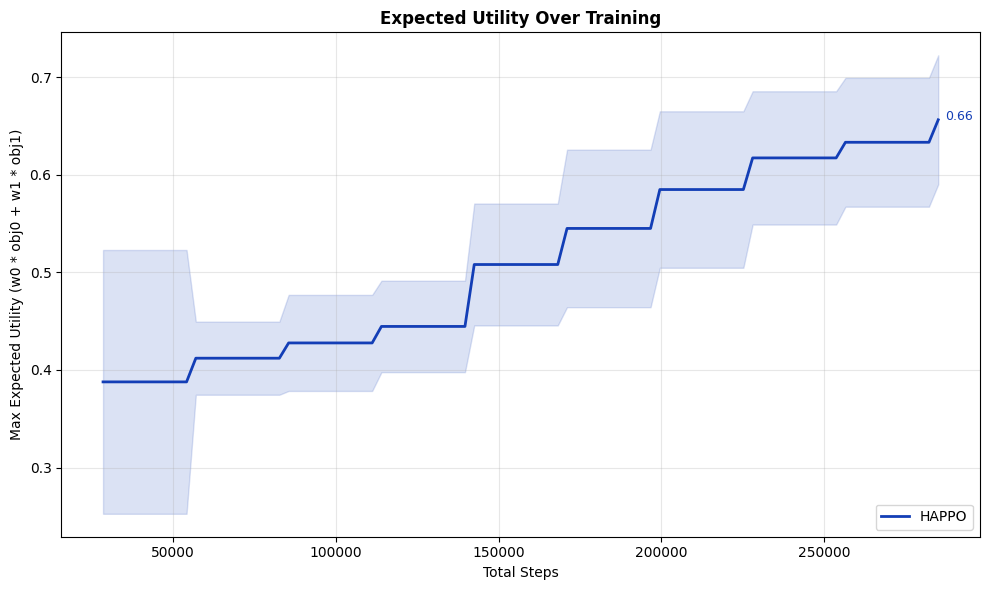

In [ ]:
eu_over_time = compute_expected_utility_over_time(histories, df)
    
if eu_over_time:
    fig_eu_time = plot_expected_utility_over_time(eu_over_time)
    if SAVE_FIGURES:
        fig_eu_time.savefig(OUTPUT_DIR / "expected_utility_over_time.png", dpi=FIGURE_DPI, bbox_inches='tight')
    plt.show()
else:
    print("No data for expected utility over time")

## 8. Training Time per Weight

In [ ]:
def fetch_training_times(runs_df, entity: str, project: str) -> pd.DataFrame:
    """Fetch training duration per run from wandb system metrics.
    Returns DataFrame with columns: run_id, algorithm, weight_idx, weight_0, weight_1, duration_min."""
    api = wandb.Api()
    rows = []
    for _, row in runs_df.iterrows():
        run_id = row["run_id"]
        run_new_id = run_id.split("-")[-1] if "-" in run_id else run_id
        try:
            run_obj = api.run(f"{entity}/{project}/{run_new_id}")
            runtime_sec = run_obj.summary.get("_runtime", 0)
            rows.append({
                "run_id": run_id,
                "algorithm": row["algorithm"],
                "weight_idx": row["weight_idx"],
                "weight_0": row["weight_0"],
                "weight_1": row["weight_1"],
                "duration_min": runtime_sec / 60.0,
            })
        except Exception as e:
            print(f"Failed to fetch runtime for {run_new_id}: {e}")
    return pd.DataFrame(rows)


def plot_training_time(time_df: pd.DataFrame) -> plt.Figure:
    """Scatter + box plot of training time per weight index, grouped by algorithm.
    Designed for many weights (e.g. 100)."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [3, 1]})
    
    algos = sorted(time_df["algorithm"].unique())
    
    # Left: scatter plot of duration vs weight_idx
    ax = axes[0]
    for algo in algos:
        algo_df = time_df[time_df["algorithm"] == algo].sort_values("weight_idx")
        color = COLORS.get(algo, "#333")
        marker = MARKERS.get(algo, "o")
        ax.scatter(algo_df["weight_idx"], algo_df["duration_min"],
                  c=color, marker=marker, s=30, alpha=0.7, label=algo, edgecolors="gray", linewidths=0.5)
        
        # Mean line
        mean_dur = algo_df["duration_min"].mean()
        ax.axhline(mean_dur, color=color, linestyle="--", alpha=0.5, linewidth=1)
    
    ax.set_xlabel("Weight Index")
    ax.set_ylabel("Training Time (minutes)")
    ax.set_title("Training Time per Weight", fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    # Right: box plot per algorithm
    ax2 = axes[1]
    box_data = [time_df[time_df["algorithm"] == algo]["duration_min"].values for algo in algos]
    bp = ax2.boxplot(box_data, labels=algos, patch_artist=True, widths=0.5)
    for patch, algo in zip(bp["boxes"], algos):
        patch.set_facecolor(COLORS.get(algo, "#333"))
        patch.set_alpha(0.6)
    ax2.set_ylabel("Training Time (minutes)")
    ax2.set_title("Distribution", fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    return fig

Fetched training times for 4 runs
Total training time: 58.6 min (1.0 hrs)

--- Training Time per Algorithm (minutes) ---
  HAPPO: mean=14.66 ± std=0.29  [min=14.31, max=14.99]  (n=4)


/tmp/ipykernel_13737/3029961889.py:54: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



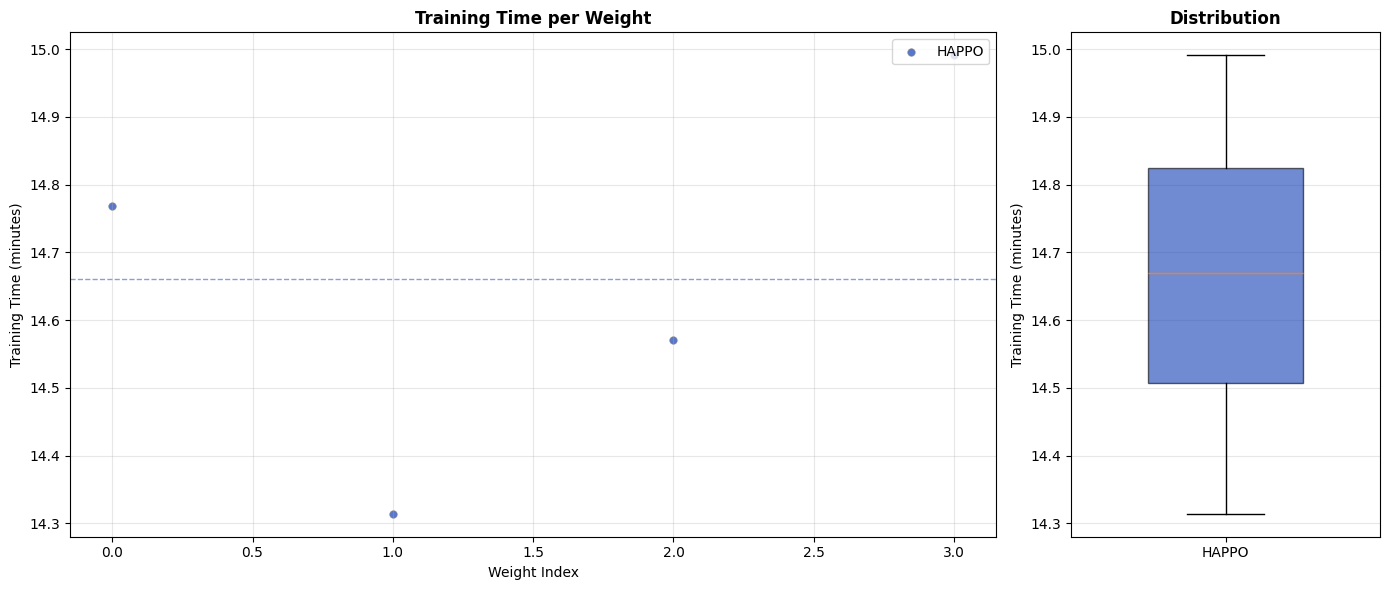

In [ ]:
if WANDB_AVAILABLE and USE_WANDB_API:
    time_df = fetch_training_times(df, WANDB_ENTITY, WANDB_PROJECT)
    print(f"Fetched training times for {len(time_df)} runs")
    print(f"Total training time: {time_df['duration_min'].sum():.1f} min ({time_df['duration_min'].sum() / 60:.1f} hrs)")
    
    print("\n--- Training Time per Algorithm (minutes) ---")
    for algo in sorted(time_df["algorithm"].unique()):
        algo_times = time_df[time_df["algorithm"] == algo]["duration_min"]
        print(f"  {algo}: mean={algo_times.mean():.2f} ± std={algo_times.std():.2f}  "
              f"[min={algo_times.min():.2f}, max={algo_times.max():.2f}]  "
              f"(n={len(algo_times)})")
    
    if not time_df.empty:
        fig_time = plot_training_time(time_df)
        if SAVE_FIGURES:
            fig_time.savefig(OUTPUT_DIR / "training_time.png", dpi=FIGURE_DPI, bbox_inches='tight')
        plt.show()
    else:
        print("No training time data available")
else:
    print("WandB not available for training time fetch")